<a href="https://colab.research.google.com/github/oleg61/--AI--/blob/main/PROJECT_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prophet seaborn

# 1. Импорт и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from statsmodels.api import OLS
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
# Установить стиль графиков
plt.style.use('seaborn-v0_8')
sns.set(style="whitegrid")

In [ ]:
drive.mount('/content/drive')

In [ ]:
# Загрузка данных
df_adv = pd.read_csv('/content/drive/MyDrive/0. DataScients (Netology)/14/adv_bad.csv', on_bad_lines='skip', sep=';')
df_sales = pd.read_csv('/content/drive/MyDrive/0. DataScients (Netology)/14/market_ls_16_20.csv', on_bad_lines='skip', sep=';')
df_prescr = pd.read_csv('/content/drive/MyDrive/0. DataScients (Netology)/14/prescriptions_16_20.csv', on_bad_lines='skip', sep=';')
df_promo = pd.read_csv('/content/drive/MyDrive/0. DataScients (Netology)/14/promo_16_20.csv', on_bad_lines='skip', sep=';')

In [ ]:
print("✅ Все данные загружены")
print("Пример строки из promo:")
print(df_promo.head())
print(df_promo.info())

✅ Все данные загружены
Пример строки из promo:
         date             brand    promotion     speciality rx_otc  \
0  01.01.2016           АЗИДРОП  reps_visits  otolaringolog     Rx   
1  01.01.2016          АЗИМИЦИН  reps_visits   terapevt_vop     Rx   
2  01.01.2016  АЗИТРОМИЦИН ЗЕНТ  reps_visits  otolaringolog     Rx   
3  01.01.2016  АЗИТРОМИЦИН ЗЕНТ  reps_visits     pharmacist     Rx   
4  01.01.2016         АКТОВЕГИН  reps_visits       neurolog    OTC   

           mnn                                          atc1_name  amount  
0  АЗИТРОМИЦИН           S СРЕДСТВА, ДЕЙСТВУЮЩИЕ НА ОРГАНЫ ЧУВСТВ     115  
1  АЗИТРОМИЦИН  J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...     115  
2  АЗИТРОМИЦИН  J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...     115  
3  АЗИТРОМИЦИН  J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...     115  
4            -                       D ДЕРМАТОЛОГИЧЕСКИЕ СРЕДСТВА     115  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272200 entries, 0 to 27219

In [ ]:
print(df_promo.columns)


Index(['date', 'brand', 'promotion', 'speciality', 'rx_otc', 'mnn',
       'atc1_name', 'amount', 'date_c2'],
      dtype='object')


# 2. Обработка дат и агрегация по кварталам

In [ ]:
# Универсальная функция для преобразования даты в квартал
def to_quarter(df, date_col, value_col):
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df['date_c2'] = df[date_col].dt.to_period('Q').dt.start_time
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    return df.groupby('date_c2')[value_col].sum().reset_index()

In [ ]:
df_adv_q = to_quarter(df_adv, 'date', 'amount').rename(columns={'amount': 'adv_amount'})
df_sales_q = to_quarter(df_sales, 'date', 'sales_packs')
df_prescr_q = to_quarter(df_prescr, 'date', 'amount').rename(columns={'amount': 'prescr_amount'})
df_promo_q = to_quarter(df_promo, 'date', 'amount')

# 3. Объединение данных в один датафрейм

In [ ]:
data_grp = df_adv_q.merge(df_sales_q, on='date_c2', how='outer') \
                   .merge(df_prescr_q, on='date_c2', how='outer') \
                   .merge(df_promo_q, on='date_c2', how='outer')

print("✅ Объединённый датафрейм создан:", data_grp.shape)
print(data_grp.head())

✅ Объединённый датафрейм создан: (20, 5)
     date_c2    adv_amount  sales_packs  prescr_amount     amount
0 2016-01-01  2.557433e+09   1317762977    107778271.0  8683624.0
1 2016-04-01  6.606662e+08   1213515023     99716201.0  8807428.0
2 2016-07-01  1.379890e+09   1240190599     96384220.0  8134529.0
3 2016-10-01  2.482576e+09   1343344486    106099704.0  8844989.0
4 2017-01-01  2.446700e+09   1281845183    104304141.0  8787983.0


# 4. Разведывательный анализ (EDA) — 4 графика
**График 1: Динамика метрик по кварталам**

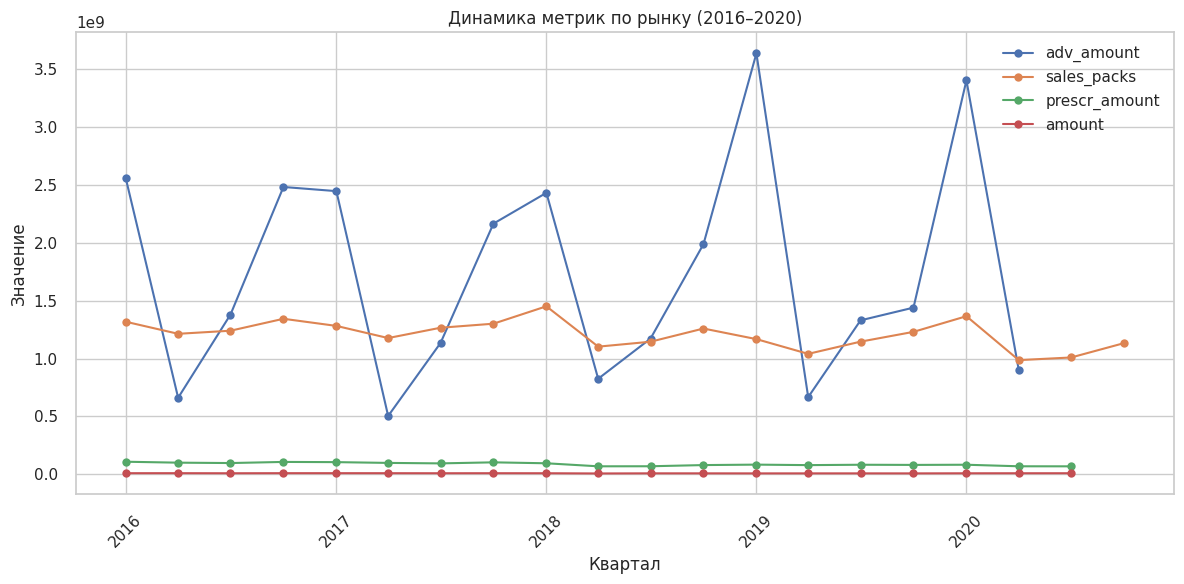

In [ ]:
plt.figure(figsize=(12, 6))
for col in ['adv_amount', 'sales_packs', 'prescr_amount', 'amount']:
    plt.plot(data_grp['date_c2'], data_grp[col], label=col, marker='o')
plt.title('Динамика метрик по рынку (2016–2020)')
plt.xlabel('Квартал')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**График 2: Корреляционная матрица (тепловая карта)**

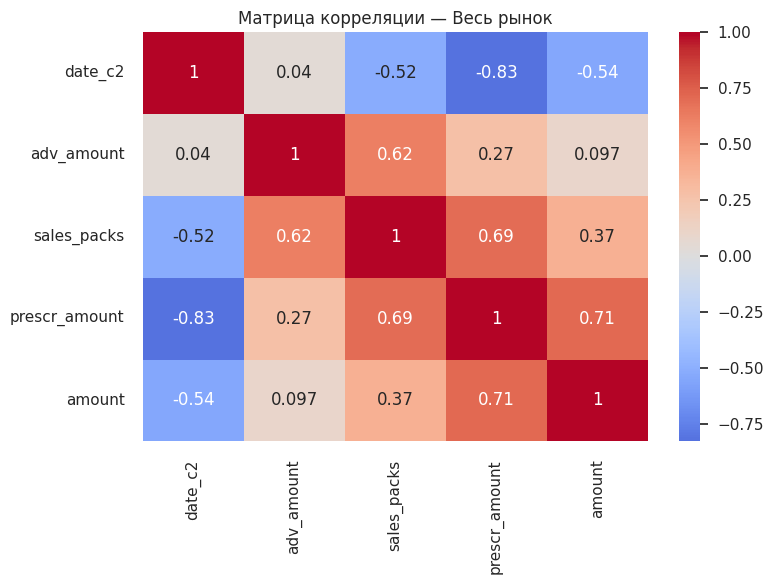

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data_grp.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляции — Весь рынок')
plt.tight_layout()
plt.show()


**График 3: Распределение продаж (гистограмма)**

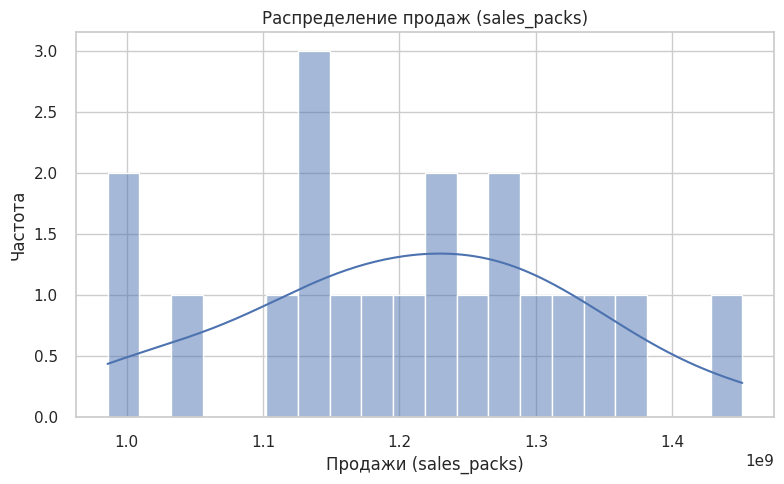

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data_grp['sales_packs'].dropna(), bins=20, kde=True)
plt.title('Распределение продаж (sales_packs)')
plt.xlabel('Продажи (sales_packs)')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()


**График 4: Диаграмма рассеяния продаж и рекламы**

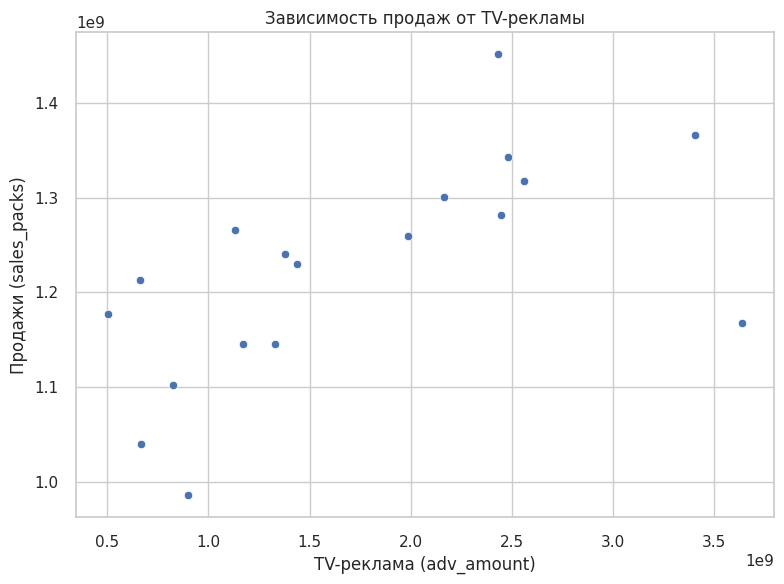

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='adv_amount', y='sales_packs', data=data_grp)
plt.title('Зависимость продаж от TV-рекламы')
plt.xlabel('TV-реклама (adv_amount)')
plt.ylabel('Продажи (sales_packs)')
plt.tight_layout()
plt.show()


# 5. Построение модели для предсказания продаж (sales_packs)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Подготовка данных: выбираем признаки и целевую переменную
data_model = data_grp.dropna(subset=['sales_packs', 'adv_amount', 'prescr_amount', 'amount']).copy()

X = data_model[['adv_amount', 'prescr_amount', 'amount']]
y = data_model['sales_packs']

# Разбиваем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Инициализация и обучение модели
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

# Метрики качества
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")


MAE: 53684330.55
RMSE: 85956994.11
R2: 0.35


# 6. Матрица корреляции и интерпретация

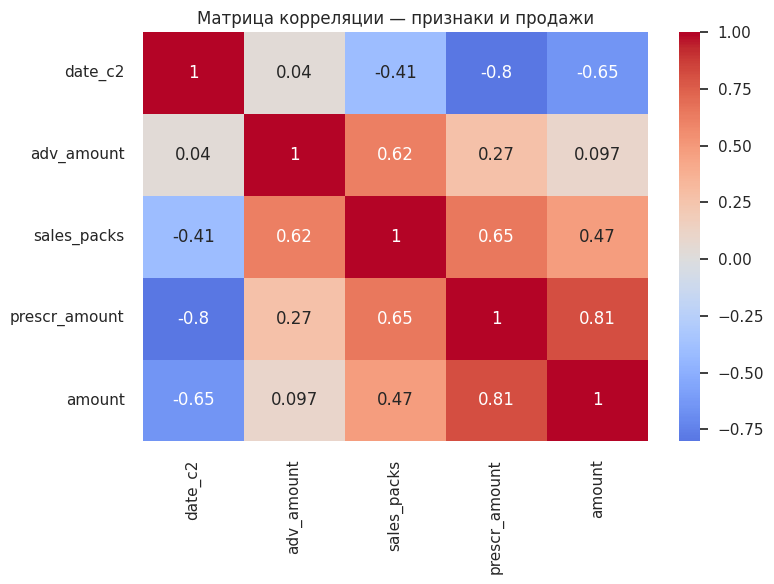

Корреляция с продажами:
sales_packs      1.000000
prescr_amount    0.648118
adv_amount       0.615935
amount           0.471912
date_c2         -0.413563
Name: sales_packs, dtype: float64


In [ ]:
corr_matrix = data_model.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляции — признаки и продажи')
plt.tight_layout()
plt.show()

print("Корреляция с продажами:")
print(corr_matrix['sales_packs'].sort_values(ascending=False))


# 7. Итоговый вывод
**Модель случайного леса показала умеренное качество предсказания продаж:**

*   R2 = 0.35 — модель объясняет около 35% вариации продаж, что говорит о наличии значительной доли нерешённых факторов и возможных сложностях в данных.
*   MAE и RMSE достаточно велики, что указывает на существенные ошибки в предсказаниях, вероятно из-за высокой вариативности или шума в данных.

**Корреляционный анализ показывает:**


*   Наибольшая положительная корреляция с продажами у количества назначений (prescr_amount, r ≈ 0.65) и TV-рекламы (adv_amount, r ≈ 0.62). Это подтверждает, что эти факторы влияют на продажи, но не полностью объясняют их динамику.
*   Столбец amount (возможно, из другого источника) также имеет умеренную корреляцию (r ≈ 0.47).
*   Отрицательная корреляция с датой (date_c2) может указывать на тренд снижения продаж во времени или сезонные эффекты.

**Выводы и рекомендации:**


*   TV-реклама и назначения действительно влияют на продажи, но для более точного прогнозирования необходимо учитывать дополнительные факторы (например, конкуренцию, сезонность, макроэкономику, качество данных).






